In [4]:
# Import libraries
from utils.load_dataset import load, load_env
from types import SimpleNamespace
from typing import NamedTuple, Optional
import jax.numpy as jnp
from dataclasses import dataclass, field

import jax
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

class Transitions(NamedTuple):
    obs: jnp.ndarray = field(default_factory=lambda: jnp.empty((0,)))
    action: jnp.ndarray = field(default_factory=lambda: jnp.empty((0,)))
    reward: jnp.ndarray = field(default_factory=lambda: jnp.empty((0,)))
    done: jnp.ndarray = field(default_factory=lambda: jnp.empty((0,)))
class Transition(NamedTuple):
    observations: jnp.ndarray
    actions: jnp.ndarray
    rewards: jnp.ndarray
    next_observations: jnp.ndarray
    dones: jnp.ndarray


In [ ]:
# Load environment and dataset
env_name="Gridworld-reacher-continous"
# env_name="MiniGrid-Reacher-extra-good"
# env_name="halfcheetah"
if env_name == "Gridworld-reacher-continous":
	config= SimpleNamespace(
		load_from_rule_based_dataset=True,
		dataset_sizes=[5, 5, 5],
		env=env_name,
		rule_based_dataset_files=[
			"datasets/Gridworld-reacher-continous/continous/data_20000_0.pkl",
			"datasets/Gridworld-reacher-continous-dr/dr/data_20000_0.pkl",
			"datasets/Gridworld-reacher-continous-lu/lu/data_20000_0.pkl",
		]
	)
elif env_name=="MiniGrid-Reacher-extra-good":
	config= SimpleNamespace(
		load_from_rule_based_dataset=True,
		dataset_sizes=[5, 5, 5],
		env=env_name,
		rule_based_dataset_files=[
            "datasets/rule_based/MiniGrid-Reacher-extra-good/batch_8000.pkl",
            "datasets/rule_based/MiniGrid-Reacher-extra-bad/batch_20000.pkl",
            "datasets/rule_based/MiniGrid-Reacher-extra-med/batch_20000.pkl",
        ]
	)
else:
	config= SimpleNamespace(
		load_from_rule_based_dataset=False,
		dataset_sizes=[5, 5, 5],
		env=env_name+'-medium-expert-v2',
		max_traj_len= 1000,
	)

dataset, idx= load(config)
print(dataset.obs.shape, dataset.action.shape, dataset.reward.shape, dataset.done.shape, idx.shape)

Dataset  0  loaded from  datasets/Gridworld-reacher-continous/continous/data_20000_0.pkl
Dataset shape: obs  (20000, 256, 10)  action  (20000, 256, 2)  reward  (20000, 256)  done  (20000, 256)
average return:  -130.48058
average length:  1.0
Dataset  1  loaded from  datasets/Gridworld-reacher-continous-dr/dr/data_20000_0.pkl
Dataset shape: obs  (20000, 256, 10)  action  (20000, 256, 2)  reward  (20000, 256)  done  (20000, 256)
average return:  -258.28683
average length:  1.0
Dataset  2  loaded from  datasets/Gridworld-reacher-continous-lu/lu/data_20000_0.pkl
Dataset shape: obs  (20000, 256, 10)  action  (20000, 256, 2)  reward  (20000, 256)  done  (20000, 256)
average return:  -266.52505
average length:  1.0
Dataset loaded, dataset size:  60000
(60000, 256, 10) (60000, 256, 2) (60000, 256) (60000, 256) (60000,)


In [ ]:
# MiniGrid-Reacher-extra-good  hot-map

import jax.numpy as jnp
import matplotlib.pyplot as plt

done_mask = jnp.cumprod(1 - dataset.done.astype(jnp.int32), axis=1)
data = (dataset.obs*done_mask[:,:,None]).sum(axis=[0,1])/done_mask.sum(axis=[0,1])
data=data.reshape(7,7,4)[:,:,1]

plt.figure(figsize=(6, 6))
plt.imshow(data, cmap="hot")
plt.colorbar()

plt.show()
plt.close()

(480000, 32, 10)
[[-1.1896477  -0.8805582 ]
 [-0.82280046 -0.83368194]
 [-1.1080421  -1.0203676 ]
 ...
 [-0.09699839  0.92218   ]
 [-0.24550909  0.83431524]
 [ 0.39575803  0.9516602 ]]


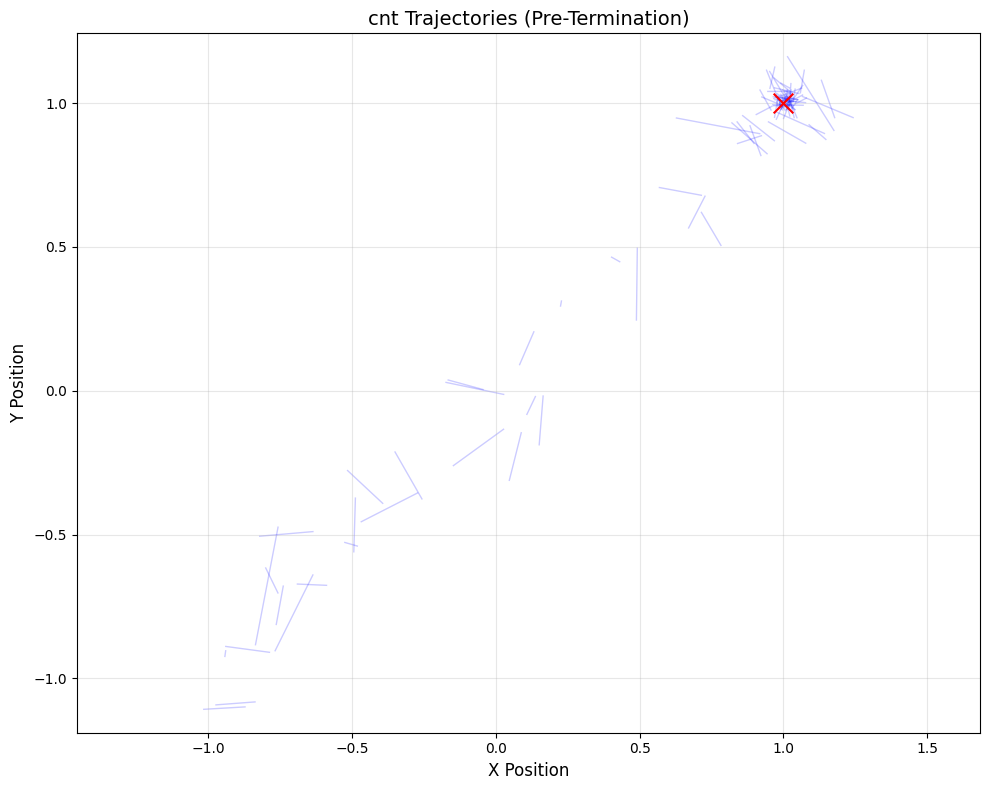

In [ ]:
# Reacher visualization

# 生成模拟数据示例（实际使用时替换为您的数据）
rng = jax.random.PRNGKey(42)
obs=dataset.obs
# done=dataset.done

cnt=100
len=32

# 随机选择cnt条轨迹
selected_idx = jax.random.choice(rng, 60000, (cnt,), replace=False)

obs=obs.reshape(-1,obs.shape[-1])
obs=obs[:obs.shape[0]-obs.shape[0]%len,:]
obs= obs.reshape(-1, len, obs.shape[-1])
print(obs.shape)

selected_obs = obs[selected_idx]  # (cnt, 256, 10)
# selected_done = done[selected_idx]  # (cnt, 256)

print(obs[:,0,0:2])
# print(done[:3,:])

# 创建画布
plt.figure(figsize=(10, 8))
ax = plt.gca()

# 从第一条轨迹提取环境常量（假设所有轨迹相同）
goal = selected_obs[0, 0, 4:6]  # 终点坐标

# 绘制终点（红色×）
plt.scatter(goal[0], goal[1], marker='x', color='red', s=50, zorder=3)

# 绘制轨迹
for i in range(cnt):
    traj = selected_obs[i]  # (256, 10)
    # traj_done = selected_done[i]  # (256,)
    
    # 找到第一个终止点
    prefix = 2
    
    # 提取有效轨迹段
    x = traj[:prefix, 0]
    y = traj[:prefix, 1]
    
    # 绘制轨迹（蓝色半透明）
    plt.plot(x, y, 'b-', alpha=0.2, linewidth=1, zorder=1)

# 美化图形
plt.xlabel('X Position', fontsize=12)
plt.ylabel('Y Position', fontsize=12)
plt.title('cnt Trajectories (Pre-Termination)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axis('equal')  # 保持比例一致
plt.tight_layout()

plt.show()
plt.close()